# Connector-lane model: a toy end-to-end example

A six-vehicle station, small enough to read every number by hand, run through
the whole pipeline:

1. **The instance**: deterministic arrivals, arranged so all three vehicle
   *cohorts* appear.
2. **FIFO simulation**: a causal policy, with a warm-up period so the measured
   window starts from a loaded station rather than an empty one.
3. **The exact model** (`offline_cl_opt`) — the optimal schedule for that same
   measured window, taking the simulation's boundary state as its initial
   condition.
4. **A certified lower bound** (`offline_cl_dw`) — Dantzig-Wolfe decomposition.
5. **Visualizations** — power and module allocation, read off the solved model.

The point of the warm-up is that a measured window never starts empty. At the
boundary some vehicles are already **plugged in** and some are already
**waiting**, and both constrain what any schedule can achieve. The three
cohorts are exactly that distinction:

| cohort | who | how the offline model treats them |
|---|---|---|
| `MEASUREMENT` | arrived after the boundary | ordinary vehicles |
| `QUEUED` | waiting in the queue at the boundary | ordinary vehicles, arrival shifted to `t=0` |
| `BOUNDARY` | already charging at the boundary | lane pinned; energy resumes from the SoC they already have |

## 1. The instance

One pile with two connectors sharing a pool of six 25 kW modules (150 kW).
Arrival times are fixed, not sampled, so the whole notebook is reproducible.

The warm-up runs for 12 minutes and the **measured window** for the following
60. Arrivals are timed to produce one of each cohort:

- EVs **0, 1** plug in during warm-up and are *still charging* at the boundary → `BOUNDARY`
- EV **2** arrives during warm-up but both connectors are busy → `QUEUED`
- EVs **3, 4, 5** arrive inside the measured window → `MEASUREMENT`

In [1]:
import numpy as np
import pandas as pd

from config import HR2MIN
from models.ev import EV
from env.charging_env import ChargingStationEnv
from policy.queue.fifo import FIFOQueuePolicy
from offline_cl_opt import StationSpec

WARMUP_MIN = 0    # warm-up: builds up a loaded station, then metrics start
MEASURE_MIN = 60.0   # the window the offline models optimise
DELTA = 1.0          # slot length (minutes) -> K = 60 slots

STATION = StationSpec(n_piles=1, n_connectors=2, n_modules=6, p_module=25.0)

# (id, arrival_min, battery_kWh, s_i, s_f). Arrival is on the whole-run clock,
# so anything below WARMUP_MIN happens during warm-up.
EV_SPECS = [
    (0,  0.0, 40.0, 0.20, 0.75),   # -> BOUNDARY  (plugs in at once, still charging at t=12)
    (1,  3.0, 40.0, 0.25, 0.75),   # -> BOUNDARY  (takes the 2nd connector)
    (2, 11.0, 100.0, 0.20, 0.75),   # -> QUEUED    (both connectors busy on arrival)
    (3, 20.0, 40.0, 0.20, 0.80),   # -> MEASUREMENT
    (4, 30.0, 100.0, 0.25, 0.80),   # -> MEASUREMENT
    (5, 42.0, 35.0, 0.25, 0.70),   # -> MEASUREMENT
]

# c_b is the simulator's internal kW*min unit, hence the HR2MIN factor.
evs = [EV(id=i, c_b=kwh * HR2MIN, s_i=s_i, s_f=s_f, arrival_time=t)
       for (i, t, kwh, s_i, s_f) in EV_SPECS]

pd.DataFrame(EV_SPECS, columns=["id", "arrival", "battery_kWh", "s_i", "s_f"]).assign(
    energy_needed_kWh=lambda d: d.battery_kWh * (d.s_f - d.s_i),
    phase=lambda d: np.where(d.arrival < WARMUP_MIN, "warm-up", "measured"),
)

,id,arrival,battery_kWh,s_i,s_f,energy_needed_kWh,phase
0,0,0.0,40.0,0.20,0.75,22.00,measured
1,1,3.0,40.0,0.25,0.75,20.00,measured
2,2,11.0,100.0,0.20,0.75,55.00,measured
3,3,20.0,40.0,0.20,0.80,24.00,measured
4,4,30.0,100.0,0.25,0.80,55.00,measured
5,5,42.0,35.0,0.25,0.70,15.75,measured


## 2. FIFO simulation

The discrete-event simulator with a first-come-first-served queue policy. It
runs warm-up **and** measured phase in one episode; at the boundary it records
who was charging and who was waiting — that snapshot is what the offline models
consume as their initial condition.

In [2]:
env = ChargingStationEnv(
    n_piles=STATION.n_piles, n_connectors=STATION.n_connectors,
    n_modules=STATION.n_modules, p_module=STATION.p_module,
    queue_capacity=10,
    mean_interarrival=None,      # None -> use the fixed `arrivals` list below
    arrivals=evs,
    max_time=MEASURE_MIN,        # length of the MEASURED phase
    warmup_period=WARMUP_MIN,
)

obs, _ = env.reset(seed=0)
rng, policy, done = np.random.default_rng(1), FIFOQueuePolicy(), False
while not done:
    mask = env.action_masks()
    ev, pile_id = policy.decide(obs, mask, rng, env.engine.station)
    obs, _, done, _, _ = env.step(pile_id, ev=ev)

m = env.engine.metrics
print(f"episode clock = {env.engine.current_time:.0f} min "
      f"(warm-up {WARMUP_MIN:.0f} + measured {MEASURE_MIN:.0f})")
print(f"arrived={len(m.arrived_evs)}  finished={len(m.finished_evs)}  dropped={len(m.dropped_evs)}")

# --- The boundary snapshot: the three cohorts ---------------------------------
print(f"\nAt the boundary (t={WARMUP_MIN:.0f}):")
for s in m.in_service_at_warmup_end:
    print(f"  BOUNDARY    EV {s.ev_id} on connector {s.connector_id}, "
          f"SoC {s.s_i:.2f} -> {s.s_current:.3f} (target {s.s_f:.2f}), "
          f"drawing {s.p_act:.0f} kW from {s.n_modules} module(s)")
for ev in m.queued_at_warmup_end:
    print(f"  QUEUED      EV {ev.id} waiting since t={ev.arrival_time:.0f}")
for ev in m.arrived_post_warmup:
    print(f"  MEASUREMENT EV {ev.id} arrives at t={ev.arrival_time:.0f}")

# --- FIFO's own schedule -------------------------------------------------------
fifo = pd.DataFrame([
    {"ev_id": ev.id, "arrival": ev.arrival_time,
     "service_start": ev.service_start_time, "departure": ev.departure_time,
     "wait": ev.service_start_time - ev.arrival_time,
     "sojourn": ev.departure_time - ev.arrival_time}
    for ev in sorted(m.finished_evs, key=lambda e: e.id)
])
print()
display(fifo)

# Measured-window sojourn per cohort. The boundary/queued vehicles are clocked
# from the BOUNDARY, not their real arrival, so these are directly comparable
# with the offline models below (which place those vehicles at a=0).
sim_by_cohort = m.sojourn_by_cohort(since=m.warmup_period)
print("FIFO mean sojourn inside the measured window:")
for name, s in sim_by_cohort.items():
    print(f"  {name:20s} n={int(s['n'])}  mean={s['mean_sojourn']:6.2f} min")

episode clock = 60 min (warm-up 0 + measured 60)
arrived=6  finished=3  dropped=0

At the boundary (t=0):
  MEASUREMENT EV 0 arrives at t=0
  MEASUREMENT EV 1 arrives at t=3
  MEASUREMENT EV 2 arrives at t=11
  MEASUREMENT EV 3 arrives at t=20
  MEASUREMENT EV 4 arrives at t=30
  MEASUREMENT EV 5 arrives at t=42



,ev_id,arrival,service_start,departure,wait,sojourn
0,0,0.0,0.000000,21.996744,0.000000,21.996744
1,1,3.0,3.000000,24.227765,0.000000,21.227765
2,2,11.0,21.996744,49.716893,10.996744,38.716893


FIFO mean sojourn inside the measured window:
  measurement          n=3  mean= 27.31 min
  measurement_queued   n=3  mean= 27.31 min
  all                  n=3  mean= 27.31 min


## 3. The exact model

`build_measurement_instance` turns the finished simulation into an offline
instance: it shifts arrivals so the measured window starts at `t=0`, folds in
the queued vehicles, and converts the already-charging ones into boundary
conditions.

Two flags carry the modelling choices:

- **`include_queued=True`** — the boundary queue is real work the schedule must
  absorb. `False` would model the window as starting with an empty queue.
- **`boundary_mode=OPTIMIZE`** — the optimizer controls the already-plugged-in
  vehicles' future power and departure, but *not* their connector (you cannot
  unplug a car mid-charge). Their energy accounting resumes from the SoC they
  already have, so they only need the remainder of `W_j`.
  The alternative, `BoundaryMode.FIXED`, pins them to exactly what the
  simulation did — useful when you want the optimizer to work *around* them
  rather than for them. (A FIXED vehicle that departs within one `delta` of the
  boundary is dropped from the instance entirely, since it occupies no whole
  slot; `inst.discarded` reports any such vehicle.)

`objective_cohorts=COHORTS_ALL` minimises total departure over all three
cohorts. Narrowing it to `COHORTS_MEASUREMENT` would still model the other
vehicles in full — they keep their connectors and modules — but stop counting
their sojourn in the objective. Either way the solution reports **all three**
cohort totals.

> **Comparing against FIFO, like for like.** The DES runs in continuous time: a
> connector passes to the next vehicle the *instant* the previous one finishes
> (here, at t = 18.87). The model works on the `delta` grid — assumption A1 puts
> every plug-in and departure on a slot boundary — so each handover costs the
> successor up to `delta` minutes. Continuous-time FIFO's mean is therefore not
> a target any grid schedule can hit, and comparing against it directly is
> apples-to-oranges.
>
> The `FIFO/grid` column comes from `metrics.grid_sojourn_by_cohort`, which
> replays FIFO's *own* schedule on the grid: each vehicle needs
> `ceil(service_minutes / delta)` slots and cannot take a connector before its
> predecessor's discretized departure. On this instance the optimum matches it
> exactly — FIFO is already optimal here. (Rounding a stay's two endpoints up
> *independently* would instead compress it — an 18.21-minute stay squeezed into
> 18 slots — and produce a target no policy can actually run. Constraint (24),
> the earliest-departure bound, rejects such a schedule outright.)

In [3]:
from offline_cl_opt import build_cl_model, solve_cl_model
from offline_cl_opt.solution import extract_solution
from offline_cl_opt.boundary import (
    BoundaryMode, build_measurement_instance,
    COHORTS_MEASUREMENT, COHORTS_MEASUREMENT_QUEUED, COHORTS_ALL,
)

inst = build_measurement_instance(
    arrived_post_warmup=m.arrived_post_warmup,
    queued_at_warmup_end=m.queued_at_warmup_end,
    in_service_at_warmup_end=m.in_service_at_warmup_end,
    warmup_period=WARMUP_MIN,
    delta=DELTA,
    horizon_minutes=MEASURE_MIN,
    include_queued=True,
    boundary_mode=BoundaryMode.OPTIMIZE,
    station=STATION,          # also runs the whole-module feasibility check
)
print(f"instance: J={len(inst.vehicles)} vehicles, discarded={inst.discarded}")
print("cohorts:", {j: c.value for j, c in sorted(inst.cohorts.items())})

instance: J=6 vehicles, discarded=[]
cohorts: {0: 'measurement', 1: 'measurement', 2: 'measurement', 3: 'measurement', 4: 'measurement', 5: 'measurement'}


In [4]:
cl_model = build_cl_model(
    inst.vehicles, STATION,
    boundary_vehicles=inst.boundary_vehicles,
    cohorts=inst.cohorts,
    objective_cohorts=COHORTS_ALL,
    # break_symmetry must stay off with boundary vehicles: their lane is pinned
    # to where they physically are, which need not respect the canonical order.
    break_symmetry=False,
    delta=DELTA,
    horizon_minutes=MEASURE_MIN,
    tie_break=True,
    bound_departures=True,
)

solve_cl_model(
    cl_model,
    mip_gap=1e-4,
    time_limit=None,
    verbose=True,
    cutoff=None)

solution = extract_solution(cl_model)

print(f"\nstatus={solution.status}  objective (total sojourn) = {solution.objective:.1f} min"
      f"  runtime={solution.runtime:.2f}s")
print(f"optimised over {solution.n_optimized}/{solution.n_vehicles} vehicles\n")

# FIFO's own schedule replayed on the model's delta grid (see the note above).
# `total_sojourn` is in the objective's own units (total sojourn, minutes).
#
# POPULATION: `solution.by_cohort` covers EVERY vehicle the model was given,
# censoring unfinished ones at D_j = K, whereas `grid_sojourn_by_cohort` covers
# FINISHED vehicles only. Comparing those two directly averages different sets
# -- and since the simulation drops precisely the longest sojourns, it can make
# the optimum look worse than FIFO for no real reason. `arrived_*` censors the
# simulation the same way the model does, so both sides cover the same
# vehicles; `censor_at` is the run's end on the simulation clock.
CENSOR_AT = WARMUP_MIN + MEASURE_MIN
grid = m.arrived_grid_sojourn_by_cohort(
    DELTA, since=m.warmup_period, censor_at=CENSOR_AT
)
sim_arrived = m.arrived_sojourn_by_cohort(since=m.warmup_period, censor_at=CENSOR_AT)
# Finished-only, for reference -- realized service quality, not comparable
# against OPT whenever the two n columns disagree.
grid_completed = m.grid_sojourn_by_cohort(DELTA, since=m.warmup_period)

print(f"{'cohort':22s} {'FIFO':>8s} {'FIFO/grid':>10s} {'OPT':>8s} "
      f"{'n':>4s} {'cens':>5s}  (arrived group)")
for name, opt in solution.by_cohort.items():
    print(f"{name:22s} {sim_arrived[name]['mean_sojourn']:8.2f} "
          f"{grid[name]['mean_sojourn']:10.2f} {opt['mean_sojourn']:8.2f} "
          f"{int(opt['n']):4d} {int(sim_arrived[name]['n_censored']):5d}")
if grid["all"]["n_censored"]:
    print(f"  ({int(grid['all']['n_censored'])} vehicle(s) censored; finished-only "
          f"grid mean would be {grid_completed['all']['mean_sojourn']:.2f} "
          f"over {int(grid_completed['all']['n'])} vehicle(s))")

fifo_total = grid["all"]["total_sojourn"]
print(f"\noptimum = {solution.objective:.1f} min vs grid-feasible FIFO = "
      f"{fifo_total:.1f} min (total sojourn) -> "
      f"{'OK, optimum is at least as good' if solution.objective <= fifo_total + 1e-6 else 'CHECK'}")

display(solution.per_vehicle)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2616613
Academic license 2616613 - for non-commercial use only - registered to m.___@mail.utoronto.ca
Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0.0001
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1145G7 @ 2.60GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Academic license 2616613 - for non-commercial use only - registered to m.___@mail.utoronto.ca
Optimize a model with 2478 rows, 1163 columns and 14748 nonzeros (Min)
Model fingerprint: 0xe6d20a53
Model has 508 linear objective coefficients and an objective constant of 360
Variable types: 762 continuous, 401 integer (281 binary)
Coefficient statistics:
  Matrix range     [2e-02, 2e+02]
  Objective range  [1e+00, 6e+01]
  Bounds range     [1e+00, 2e+02]
  RHS range        [1e+00, 2

,vehicle_id,cohort,boundary_mode,in_objective,arrival,served,pile,connector,start_slot,departure_slot,sojourn_min,energy_kwh,energy_delivered_before_kwh,energy_required_kwh
0,0,measurement,None,True,0.0,True,0,0,0.0,22.0,22.0,22.000000,0.0,22.00
1,1,measurement,None,True,3.0,True,0,1,3.0,24.0,21.0,20.000000,0.0,20.00
2,2,measurement,None,True,11.0,True,0,1,24.0,58.0,47.0,55.000000,0.0,55.00
3,3,measurement,None,True,20.0,True,0,0,22.0,49.0,29.0,24.000000,0.0,24.00
4,4,measurement,None,True,30.0,True,0,0,49.0,60.0,30.0,10.833333,0.0,55.00
5,5,measurement,None,True,42.0,True,0,1,59.0,60.0,18.0,0.000000,0.0,15.75


In [12]:
from offline_cl_PB import solve_branch_and_price, schedule_from_simulation

# --- Incumbent from the FIFO simulation ---------------------------------------
# The simulation's plug-in order and pile choices, rebuilt on the slot grid with
# whole modules. Each vehicle starts on its simulated pile at the first slot
# (from floor(service_start/delta) on) where a connector is free and it can still
# finish; if it cannot finish inside the horizon it is moved to its best start on
# any pile, and failing that left unserved (D = K). So the result is always a
# FEASIBLE schedule -- never a fake UB -- and the solver re-validates it anyway
# (an invalid initial_schedule raises instead of being used).
K = int(round(MEASURE_MIN / DELTA))
sim_schedule, sim_counts = schedule_from_simulation(
    m.arrived_evs, inst.vehicles, STATION, DELTA, K, inst.boundary_vehicles,
    warmup_period=WARMUP_MIN,
)
print("simulation incumbent: total sojourn =",
      sum(DELTA * sim_schedule[v.id].departure - v.a for v in inst.vehicles), "min", sim_counts)

sol = solve_branch_and_price(inst.vehicles, STATION, DELTA, MEASURE_MIN,
                             boundary_vehicles=inst.boundary_vehicles, cohorts=inst.cohorts,
                             objective_cohorts=COHORTS_ALL,
                             initial_schedule=sim_schedule,
                             time_limit=1800, progress=True)
print(sol.status, "objective", sol.objective, "lower bound", sol.lower_bound,
      "| best schedule came from:", sol.incumbent_source)

simulation incumbent: sum D_j = 275 {'followed_simulation': 3, 'moved': 0, 'unserved': 3, 'not_started_in_simulation': 1}
[B&P      0.0s] incumbent 275 from greedy list schedule
[B&P      0.0s]   node -1 iter 1: z_RMP=274.6667 LB=255.5000 UB=275 added=13 cols=27 pricing=0.00s
[B&P      0.2s]   node -1 iter 10: z_RMP=270.4772 LB=259.2761 UB=275 added=13 cols=148 pricing=0.04s
[B&P      0.8s]   node -1 iter 20: z_RMP=268.3975 LB=265.5452 UB=275 added=9 cols=242 pricing=0.08s
[B&P      1.4s]   node -1 iter 30: z_RMP=268.2542 LB=267.8333 UB=275 added=7 cols=303 pricing=0.06s
[B&P      1.8s]   node -1 iter 36: z_RMP=268.2308 LB=268.0128 UB=275 added=3 cols=331 pricing=0.06s (early branch)
[B&P      1.8s]   node -1 iter 1: z_RMP=272.8462 LB=266.6615 UB=275 added=8 cols=339 pricing=0.01s
[B&P      2.0s]   node -1 iter 10: z_RMP=272.5000 LB=271.9534 UB=275 added=3 cols=390 pricing=0.02s
[B&P      2.0s]   node -1 iter 11: z_RMP=272.5000 LB=272.1089 UB=275 added=3 cols=393 pricing=0.01s (early b

In [13]:
# The branch-and-price schedule as a solved compact model (ConnectorLaneModel):
# a drop-in replacement for `cl_model` in extract_solution and in the plots of
# section 5 -- e.g. plot_vehicle_power_and_modules(cl_model_bp, ...).
cl_model_bp = sol.to_cl_model()
solution_bp = extract_solution(cl_model_bp)
print(f"status={solution_bp.status}  objective={solution_bp.objective:.1f}  "
      f"(compact model above: {solution.objective:.1f})")

status=OPTIMAL  objective=273.0  (compact model above: 273.0)


## 4. Certified lower bound — Dantzig-Wolfe

The same instance solved by decomposition: a master problem picks one whole
schedule ("column") per vehicle, and per-vehicle pricing subproblems generate
new columns on demand.

It returns a **bracket**, not a single number. `LB` is a certified lower bound
on the true optimum, valid at every iteration; `UB` is a genuine feasible
schedule from price-and-branch. The exact objective above must lie inside it —
which is the assertion at the end of the cell.

On an instance this small the exact model is the faster route to the optimum;
the decomposition earns its keep at scale, where the compact MILP stops
closing.

In [14]:
from offline_cl_dw import solve_by_decomposition

dw_solution, dw_colgen = solve_by_decomposition(
    inst.vehicles, STATION,
    boundary_vehicles=inst.boundary_vehicles,
    cohorts=inst.cohorts,
    objective_cohorts=COHORTS_ALL,   # same choice as the exact model above
    delta=DELTA,
    horizon_minutes=MEASURE_MIN,
    gamma=0.0,
    time_limit=None,
    purge_every=None,
    gap_tolerance=.000001,
    #gap_tolerance=len(inst.vehicles) * 1,  # 1 min of mean-sojourn uncertainty
    progress=True,
)

print(f"bracket: [{dw_solution.LB:.2f}, {dw_solution.UB:.2f}]  gap={dw_solution.gap:.2f}"
      f"  converged={dw_solution.converged}  iterations={dw_solution.iterations}")
print(f"mean sojourn: LB={dw_solution.mean_sojourn_LB:.2f}  "
      f"UB={dw_solution.mean_sojourn_UB:.2f} min")
print(f"whole-module feasible: {dw_solution.whole_module_feasible}")
print(f"exact objective from section 3: {solution.objective:.2f}")

assert dw_solution.LB <= solution.objective + 1e-4, "LB must not exceed the true optimum"
assert dw_solution.UB >= solution.objective - 1e-4, "UB must be an achievable schedule"
print("\nOK: LB <= exact optimum <= UB")

[colgen] iter 1: z_RMP=284.526, best_LB=226.210, gap=58.316, exact=True, candidates=6, columns_added=6, total_columns=18
[colgen] iter 2: z_RMP=284.467, best_LB=232.085, gap=52.381, exact=True, candidates=5, columns_added=5, total_columns=23
[colgen] iter 3: z_RMP=272.978, best_LB=241.008, gap=31.971, exact=True, candidates=5, columns_added=5, total_columns=28
[colgen] iter 4: z_RMP=272.927, best_LB=241.008, gap=31.919, exact=True, candidates=5, columns_added=5, total_columns=33
[colgen] iter 5: z_RMP=269.648, best_LB=241.008, gap=28.640, exact=True, candidates=5, columns_added=5, total_columns=38
[colgen] iter 6: z_RMP=269.365, best_LB=241.862, gap=27.503, exact=True, candidates=5, columns_added=5, total_columns=43
[colgen] iter 7: z_RMP=268.858, best_LB=246.588, gap=22.270, exact=True, candidates=5, columns_added=5, total_columns=48
[colgen] iter 8: z_RMP=268.439, best_LB=257.939, gap=10.499, exact=True, candidates=5, columns_added=5, total_columns=53
[colgen] iter 9: z_RMP=268.393, 

## 5. Visualizations

Both plots are read straight off the solved MILP's decision variables — not
from the simulator.

**Per vehicle:** power drawn each slot (bars), the reconstructed BMS acceptance
limit (dashed), and the module capacity that draw actually requires
(dashed step). Where the bars sit below the dashed BMS line, the *station* is
the binding constraint, not the battery.

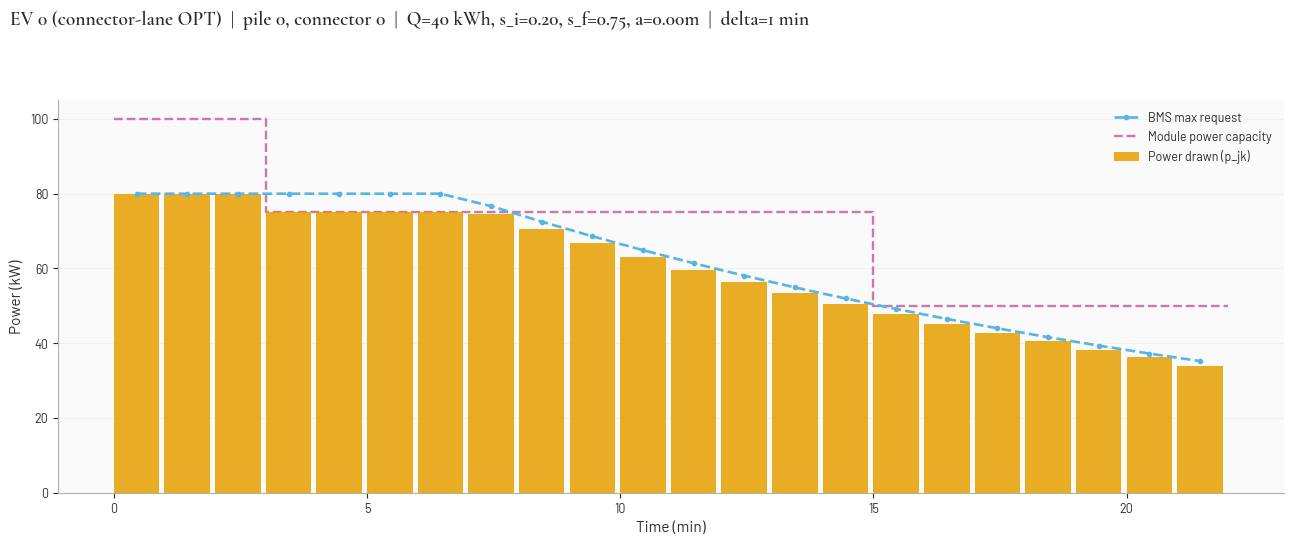

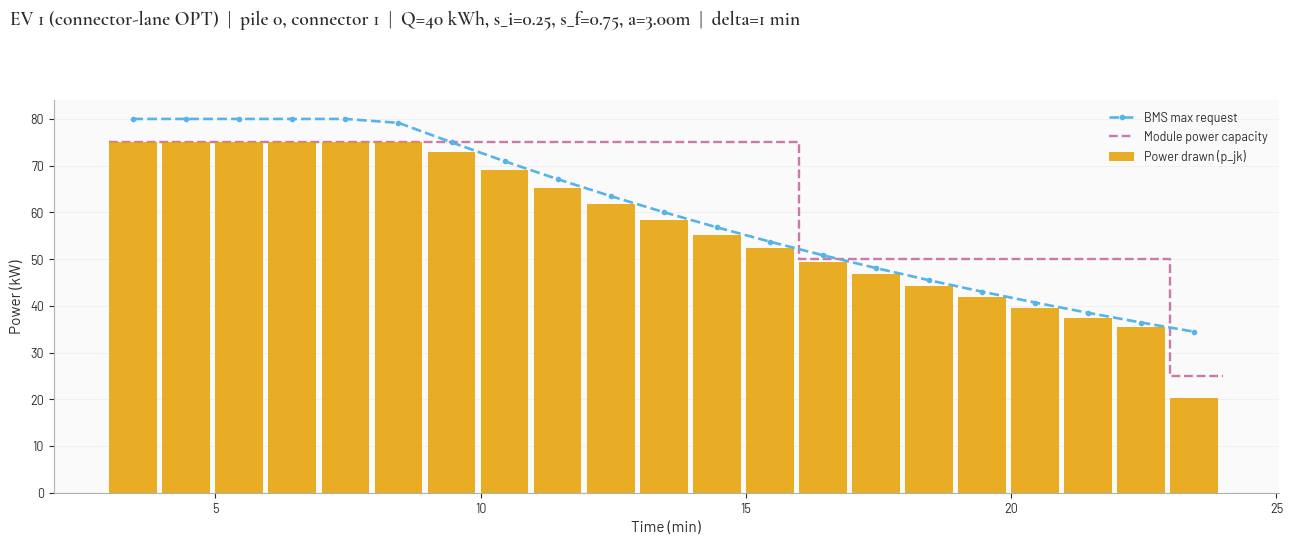

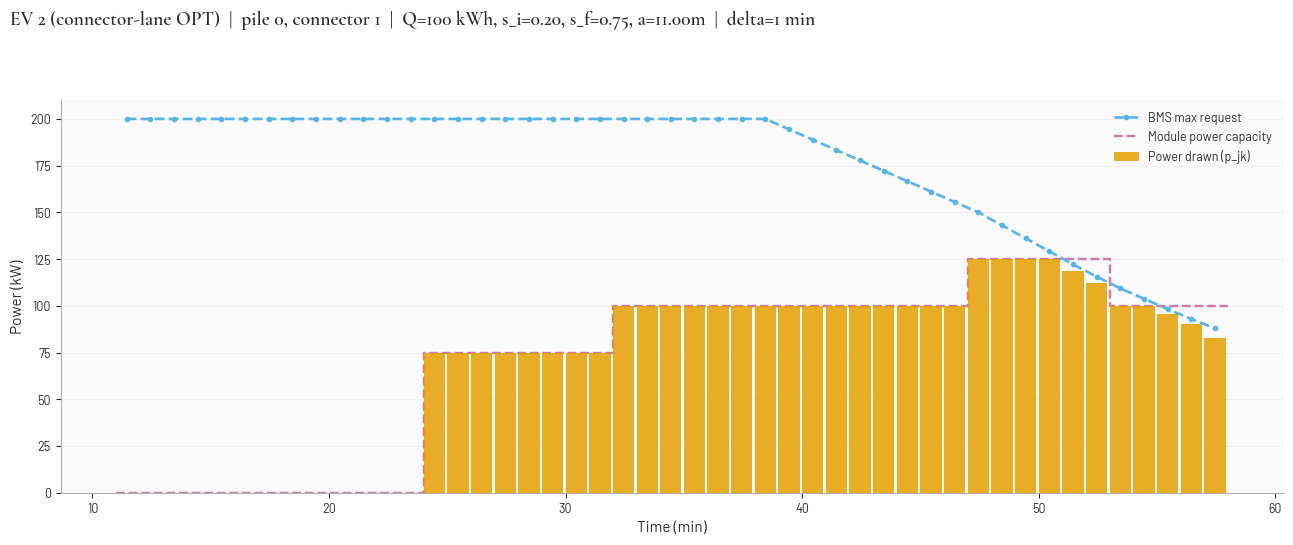

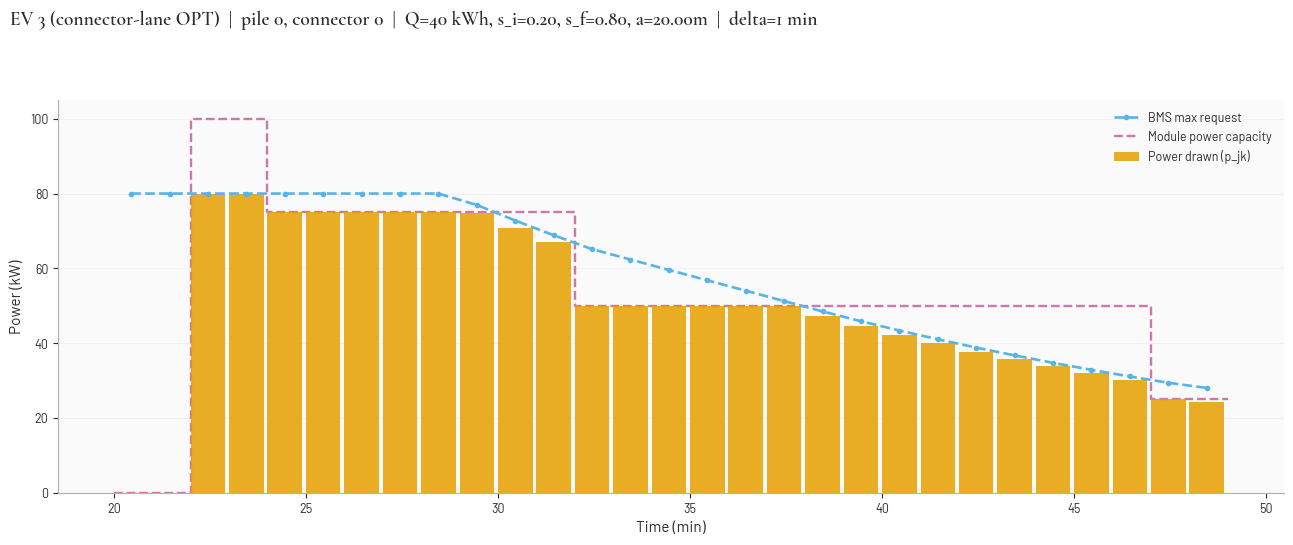

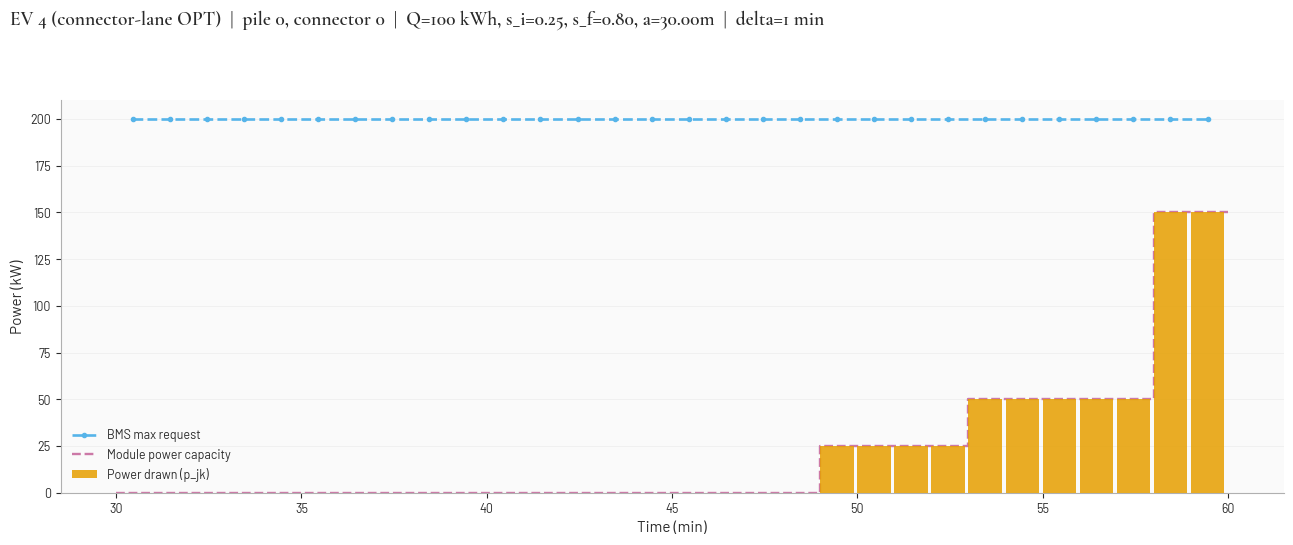

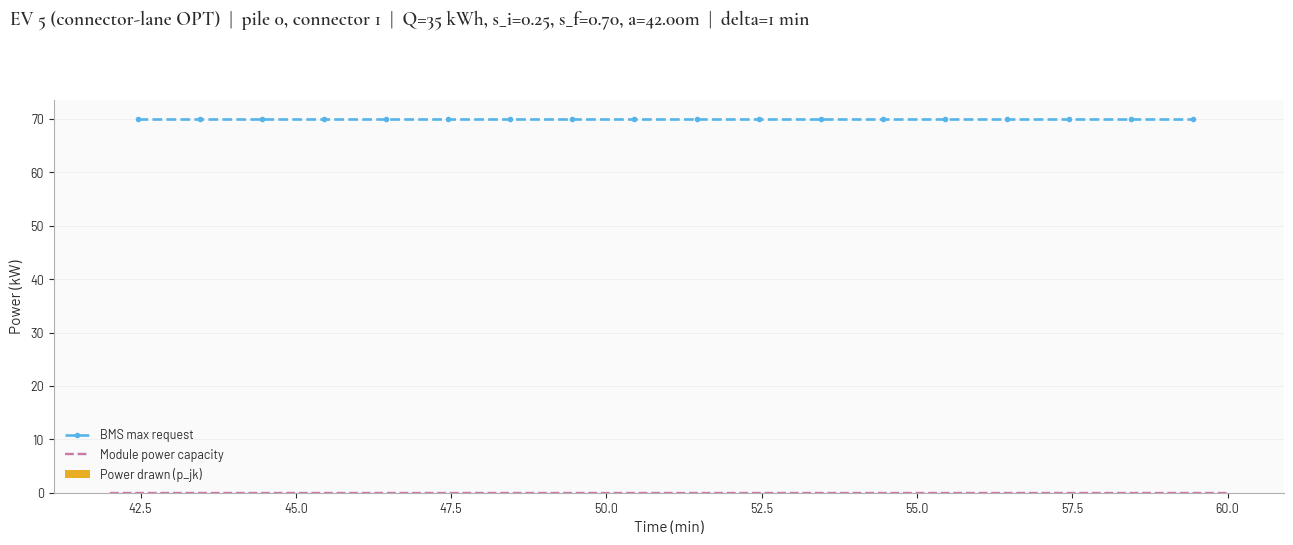

In [18]:
from offline_cl_opt import plot_vehicle_power_and_modules

figs = plot_vehicle_power_and_modules(cl_model, [v.id for v in inst.vehicles])
for fig in figs:
    display(fig)

**Per pile:** one subplot per connector, with the other connector's draw stacked
on top so the total bar height reads as the pile's total draw. The dotted line
is the pile's 150 kW capacity — the shared module pool the two connectors
compete for.

In [9]:
# Save the incumbent next to the notebook. This is the schedule the plots
# read (p, u, y, ...). It is not the branch-and-bound tree, so it cannot
# resume the proof of optimality.
from pathlib import Path

OUT = Path("cl_model_saved")
OUT.mkdir(exist_ok=True)
cl_model.model.write(str(OUT / "cl_model.sol"))
print(f"wrote {OUT / 'cl_model.sol'}")

wrote cl_model_saved\cl_model.sol


In [10]:
# Rebuild the empty model (seconds), then install the saved incumbent.
# SolutionLimit=1 stops as soon as that solution is accepted, so this is a
# feasibility check, not a new search. Status will be SOLUTION_LIMIT, which
# is enough for extract_solution and the plot helpers.
from pathlib import Path
from offline_cl_opt import build_cl_model

OUT = Path("cl_model_saved")
cl_model_loaded = build_cl_model(
    inst.vehicles, STATION,
    boundary_vehicles=inst.boundary_vehicles,
    cohorts=inst.cohorts,
    objective_cohorts=COHORTS_ALL,
    break_symmetry=False,
    delta=DELTA,
    horizon_minutes=MEASURE_MIN,
    tie_break=True,
    bound_departures=True,
)
cl_model_loaded.model.read(str(OUT / "cl_model.sol"))
cl_model_loaded.model.Params.SolutionLimit = 1
cl_model_loaded.model.optimize()

solution = extract_solution(cl_model_loaded)
print(solution.status, solution.objective)

SUBOPTIMAL 273.0


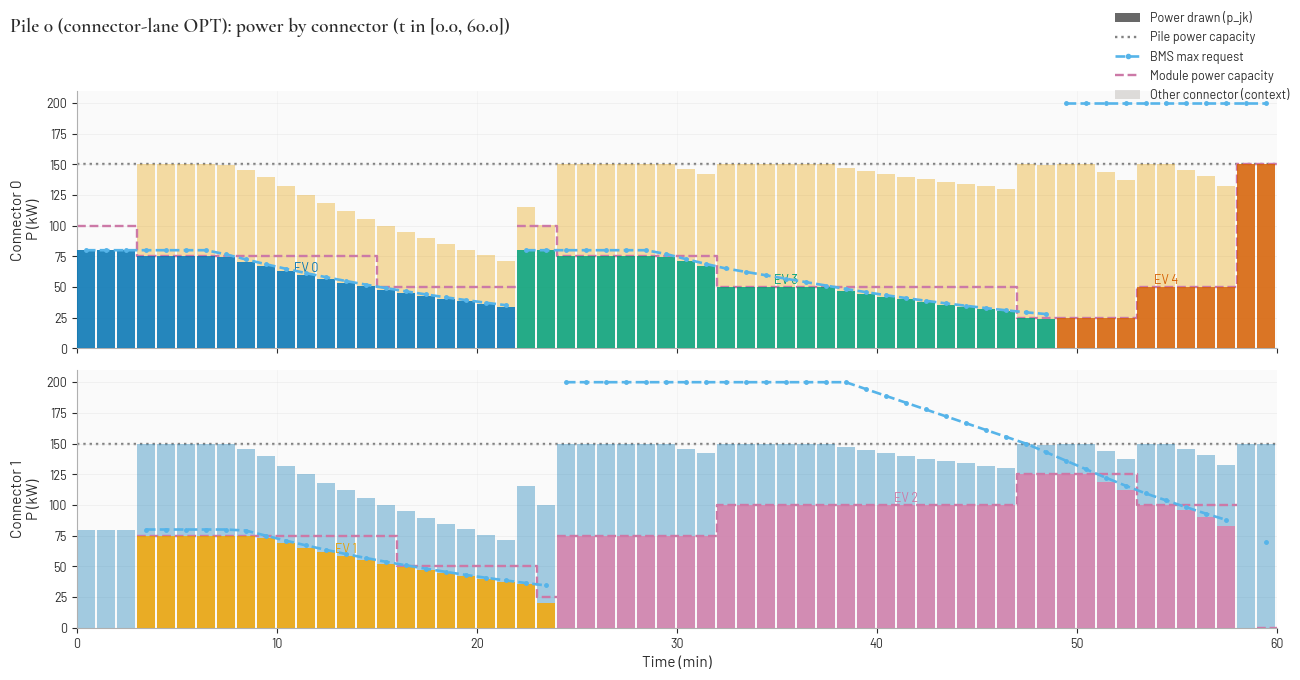

In [19]:
from offline_cl_opt import plot_pile_power_and_modules

plot_pile_power_and_modules(
    cl_model, pile_id=0,
    stack_other_connectors=True,
    show_pile_capacity=True,
)

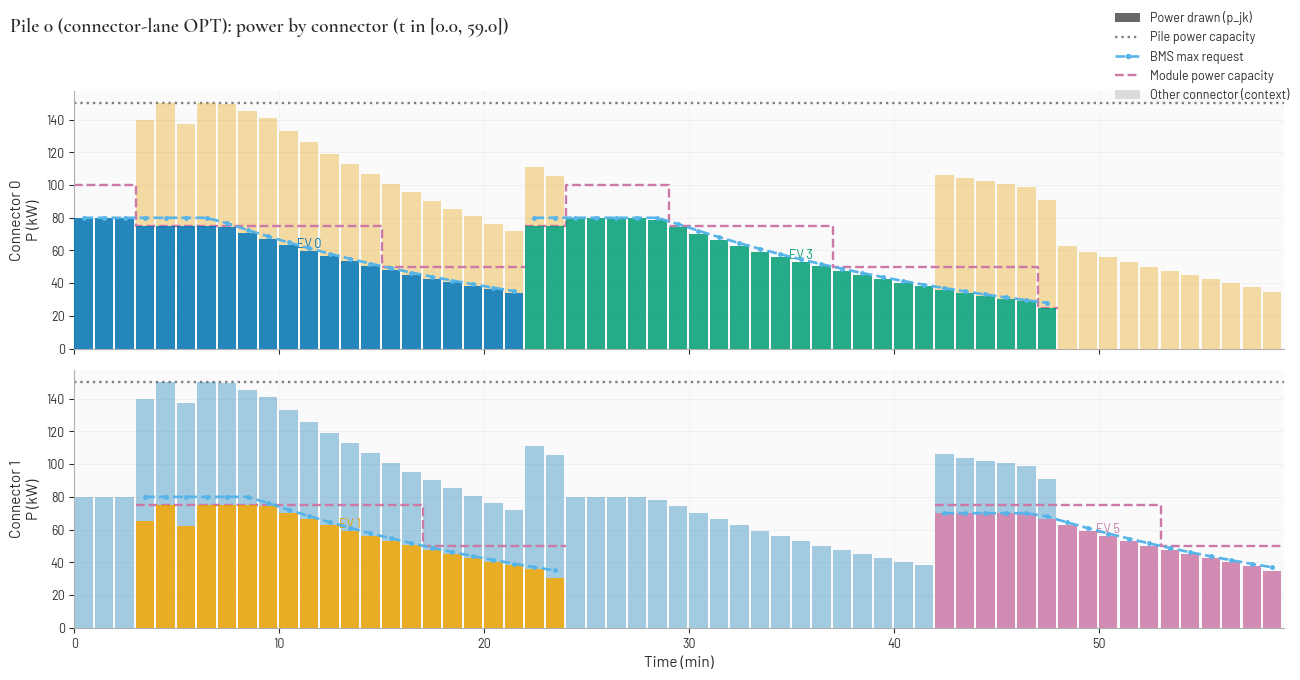

In [20]:
from offline_cl_opt import plot_pile_power_and_modules

plot_pile_power_and_modules(
    cl_model_bp, pile_id=0,
    stack_other_connectors=True,
    show_pile_capacity=True,
)